In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load CSV
df = pd.read_csv("logs.csv")


In [122]:
num_unique_pairs = df.groupby(['source_ip', 'dest_ip']).ngroups
print("Number of unique pairs:", num_unique_pairs)

pair_counts = df.groupby(['source_ip', 'dest_ip','action']).size().reset_index(name='count')
top_pairs = pair_counts.sort_values(by='count', ascending=False).head(10)
print(top_pairs)

Number of unique pairs: 89916
              source_ip        dest_ip   action  count
127901     192.168.1.63   192.168.1.47  blocked     63
170370    59.198.75.253  192.168.1.185  allowed     62
10701   150.110.230.150  192.168.1.113  blocked     61
12223    161.77.216.164  192.168.1.112  blocked     61
165649    43.68.136.224  192.168.1.117  blocked     60
10496    144.138.68.192  192.168.1.250  allowed     60
151686    21.219.60.222  192.168.1.235  allowed     60
153660    217.89.155.68  192.168.1.209  allowed     60
148809    207.105.49.25   192.168.1.83  blocked     60
172646    64.224.237.20   192.168.1.66  allowed     59


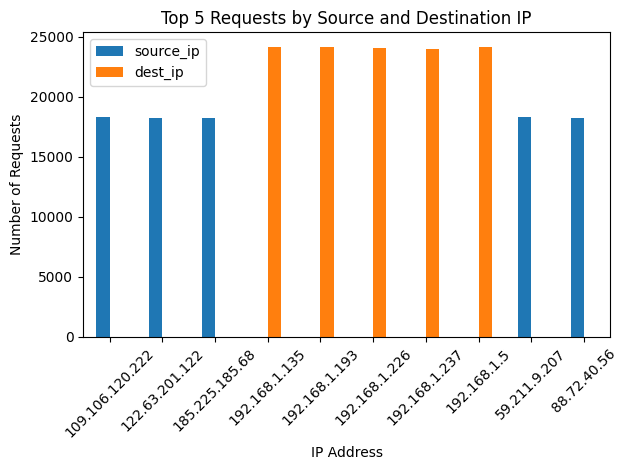

In [102]:
# Combine top IPs into one DataFrame for plotting
top_sources = df['source_ip'].value_counts().head(5)
top_dests = df['dest_ip'].value_counts().head(5)

combined = pd.DataFrame({
    'source_ip': top_sources,
    'dest_ip': top_dests
}).fillna(0)

combined.plot(kind='bar')
plt.title("Top 5 Requests by Source and Destination IP")
plt.xlabel("IP Address")
plt.ylabel("Number of Requests")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

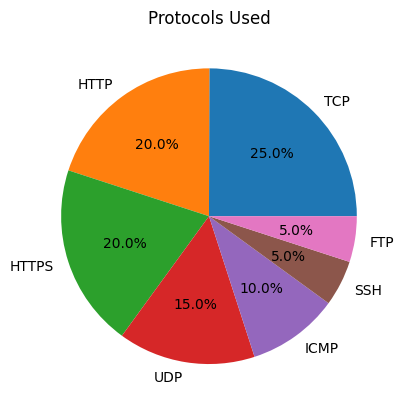

In [103]:
df['protocol'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Protocols Used")
plt.ylabel("")
plt.show()

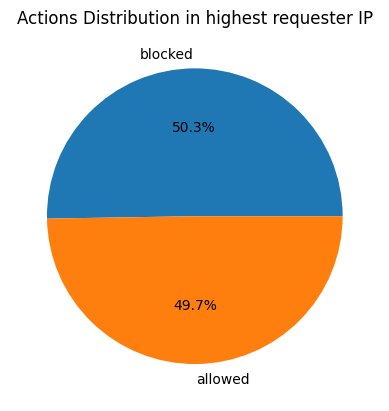

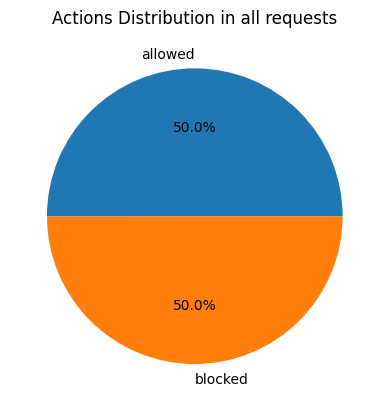

In [113]:

ip = df[df.source_ip == "59.211.9.207"]
ip['action'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Actions Distribution in highest requester IP")
plt.ylabel("")
plt.show()

df['action'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Actions Distribution in all requests")
plt.ylabel("")
plt.show()

In [95]:

import pandas as pd

# ----------------------------
# Load data
# ----------------------------
df = pd.read_csv("logs.csv")

# Convert timestamp
df['timestamp'] = pd.to_datetime(df['timestamp'])

# ----------------------------
# Build ts dataframe (your version)
# ----------------------------
df = (
    df.groupby('timestamp')
      .size()
      .reset_index(name='requests')
      .rename(columns={'timestamp': 'time'})
)

# Parse datetime
df["time"] = pd.to_datetime(df["time"])

# Set index
df.set_index("time", inplace=True)

# Sort index
df.sort_index(inplace=True)

# ----------------------------
# Resampling
# ----------------------------
daily = df["requests"].resample("D").sum()
weekly = df["requests"].resample("W").sum()
monthly = df["requests"].resample("ME").sum()

# ============================================================
# 🔍 MISSING DAYS DETECTION (ADDED PART)
# ============================================================

# Full expected daily range
full_days = pd.date_range(
    start=daily.index.min(),
    end=daily.index.max(),
    freq="D"
)

# Days that actually exist in your resampled data
existing_days = daily.index

# Missing days = expected - existing
missing_days = full_days.difference(existing_days)

print("\nMissing days:")
print(missing_days)

# ----------------------------
# Optional: create coverage dataframe
# ----------------------------
calendar = pd.DataFrame({"date": full_days})
calendar["present"] = calendar["date"].isin(existing_days)

print("\nCoverage sample:")
print(calendar.head())



Missing days:
DatetimeIndex([], dtype='datetime64[us]', freq='D')

Coverage sample:
        date  present
0 2024-01-01     True
1 2024-01-02     True
2 2024-01-03     True
3 2024-01-04     True
4 2024-01-05     True


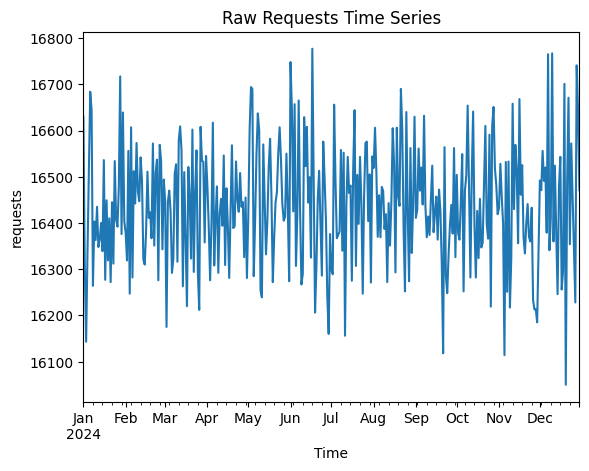

In [96]:

# === 5. Plot time series ===
plt.figure()
df["requests"].plot(title="Raw Requests Time Series")
plt.xlabel("Time")
plt.ylabel("requests")
plt.show()


time
0    16456.301887
1    16419.846154
2    16434.230769
3    16443.211538
4    16430.134615
5    16450.903846
6    16433.519231
Name: requests, dtype: float64


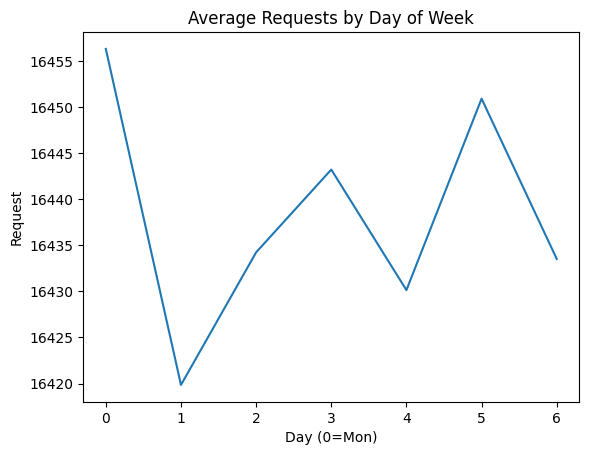

In [97]:

dow_pattern = df.groupby(df.index.dayofweek)["requests"].mean()
print(dow_pattern)
dow_pattern.plot(title="Average Requests by Day of Week")
plt.xlabel("Day (0=Mon)")
plt.ylabel("Request")
plt.show()

In [98]:

month_pattern = df.groupby(df.index.month)["requests"].mean()
print(month_pattern)



time
1     16423.806452
2     16440.517241
3     16429.967742
4     16418.300000
5     16465.870968
6     16452.533333
7     16438.838710
8     16459.935484
9     16417.066667
10    16450.225806
11    16395.433333
12    16466.566667
Name: requests, dtype: float64
